In [1]:
import json
import os
import sys
from types import SimpleNamespace

import dill
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
from matplotlib.colors import LogNorm
from simpeg.electromagnetics.utils.em1d_utils import get_vertical_discretization
from simpeg.utils import plot_1d_layer_model
from ipywidgets import VBox, interactive_output, widgets


In [2]:
if os.path.basename(os.getcwd()) == "notebooks":
    print(os.getcwd())
    os.chdir("..")
print(os.getcwd())
sys.path.append("tools")
from tools import binning

/Volumes/X31/01.Projects/atem/notebooks
/Volumes/X31/01.Projects/atem
Current working directory is changed to: /Volumes/X31/01.Projects/atem


In [3]:
with open("./outputs/doi2/ref_m0/m0_inv_results_atem_full.pik", "rb") as f:
    m0 = dill.load(f)

with open("./outputs/doi2/ref_m0/m0_soundings.json") as f:
    m0_soundings = json.load(f)

with open("./outputs/doi2/ref_m1/m1_inv_results_atem_full.pik", "rb") as f:
    m1 = dill.load(f)

with open("./outputs/doi2/ref_m1/m1_soundings.json") as f:
    m1_soundings = json.load(f)

In [4]:
phi_d0 = [m0[i+1]["phi_d"] for i in range(len(m0))]
phi_m0 = [m0[i+1]["phi_m"] for i in range(len(m0))]
phi_d1 = [m1[i+1]["phi_d"] for i in range(len(m1))]
phi_m1 = [m1[i+1]["phi_m"] for i in range(len(m1))]

In [5]:
type(m0[1]["dpred"].shape[0])

int

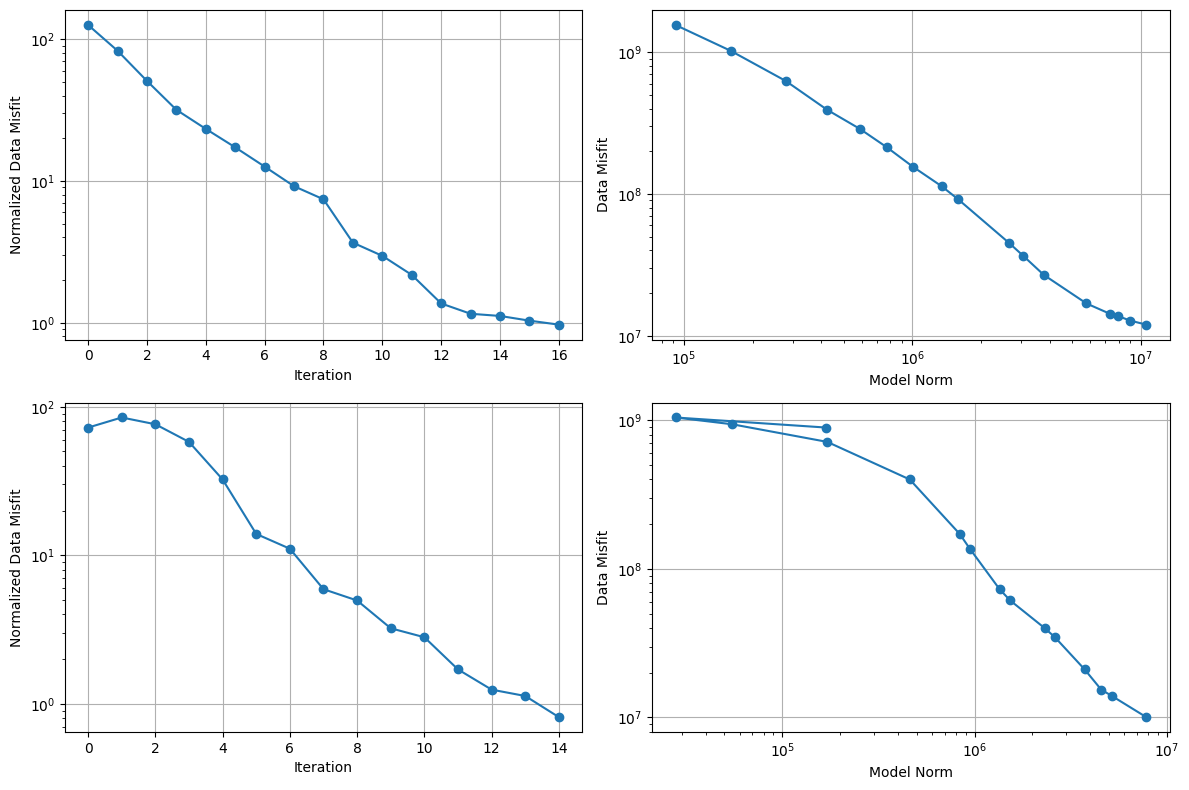

In [6]:
plt.figure(figsize=(12, 8))
plt.subplot(2,2,1)
plt.semilogy([i for i in range(len(phi_d0))], np.array(phi_d0)/m0[1]["dpred"].shape[0], "o-")
plt.grid()
plt.xlabel("Iteration")
plt.ylabel("Normalized Data Misfit")
plt.subplot(2,2,2)
plt.loglog(phi_m0, phi_d0, "o-")
plt.xlabel("Model Norm")
plt.ylabel("Data Misfit")
plt.grid()
plt.subplot(2,2,3)
plt.semilogy([i for i in range(len(phi_d1))], np.array(phi_d1)/m1[1]["dpred"].shape[0], "o-")
plt.grid()
plt.xlabel("Iteration")
plt.ylabel("Normalized Data Misfit")
plt.subplot(2,2,4)
plt.loglog(phi_m1, phi_d1, "o-")
plt.xlabel("Model Norm")
plt.ylabel("Data Misfit")
plt.grid()
plt.tight_layout()

In [7]:
m0_keys = m0.keys()
m1_keys = m1.keys()

In [8]:
# Soundings
saved_soundings = [int(Val) for Val in m0_soundings]

In [9]:
def doi_index(m0, m1, m0r, m1r):
    numerator = np.abs(m0 - m1)
    denominator = np.abs(m0r - m1r)
    r = numerator / denominator
    return r

In [10]:
areas = ["NW", "NE", "SE", "SW", "tielines"]
output_prefix = "merged"
dx = 50.0
istart_channel = 3
iend_channel = 25

criteria_rerr = 0.05
criteria_uncertainty = 0.05
bad_line_uncertainty = 0.30
floors_c = 0.05


def rebuild_merged_binned_frames(areas, dx=50.0):
    all_values = []
    all_values_std = []
    all_soundings = []

    times = None
    n_turns = None
    dheader = None
    picker = None

    for area in areas:
        tmp = binning(dx=dx, area=area)
        if times is None:
            times = tmp["times"]
            n_turns = tmp["n_turns"]
            dheader = tmp["dheader"]
            picker = tmp["picker"]

        all_values.extend(tmp["values"])
        all_values_std.extend(tmp["values_std"])
        all_soundings.extend(tmp["soundings"])

    if not all_values:
        raise ValueError("No binned data were reconstructed from the requested areas.")

    df_data_binned = pd.DataFrame(
        data=np.vstack(all_values),
        columns=["Line", "distance"] + picker[1:],
    )
    df_data_std_binned = pd.DataFrame(
        data=np.vstack(all_values_std),
        columns=["bheight"] + dheader,
    )

    for col in df_data_binned.columns:
        if col == "Line":
            df_data_binned[col] = df_data_binned[col].astype(str)
        else:
            df_data_binned[col] = pd.to_numeric(df_data_binned[col], errors="coerce")

    for col in df_data_std_binned.columns:
        df_data_std_binned[col] = pd.to_numeric(
            df_data_std_binned[col], errors="coerce"
        )

    return {
        "times": np.asarray(times, dtype=float),
        "soundings": [int(val) for val in all_soundings],
        "n_turns": float(n_turns),
        "dheader": list(dheader),
        "picker": list(picker),
        "df_data_binned": df_data_binned,
        "df_data_std_binned": df_data_std_binned,
    }

merged_data = rebuild_merged_binned_frames(areas=areas, dx=dx)
times = merged_data["times"]
soundings = merged_data["soundings"]
n_turns = merged_data["n_turns"]
dheader = merged_data["dheader"]
picker = merged_data["picker"]
df_data_binned = merged_data["df_data_binned"]
df_data_std_binned = merged_data["df_data_std_binned"]
line_no = list(df_data_binned["Line"].unique())

In [11]:
def plot_data(line, x):
    print(line)
    x_line = x[x["Line"]==line]

    fig, axs = plt.subplots(2,1, figsize=(20, 10), constrained_layout=True)
    ax0, ax1 = axs

    # (ax0) Plot the binned locations
    ax0.plot(x["x_wgs84"], x["y_wgs84"], '.')
    ax0.plot(x_line["x_wgs84"], x_line["y_wgs84"], '.')
    ax0.plot(x_line["x_wgs84"].values[0], x_line["y_wgs84"].values[0], 'o')
    ax0.set_aspect(0.2)

    # (ax1) Plot the normalized data
    ax2 = ax1.twinx()
    ax1.semilogy(x_line['distance'], np.abs(x_line[dheader]), color='k', lw=2)
    ax2.plot(x_line['distance'], x_line['bheight'], '-', label='Flight height', lw=1.5, color='magenta')
    ax2.legend()
    plt.title(f"Line: {line}")

In [12]:
for col in df_data_binned.columns:
    if col != "Line":
        df_data_binned[col] = pd.to_numeric(df_data_binned[col])

print(f"\tBinned soundings: {len(df_data_binned):,}\n")

# Criteria for bad data (uncertainty correction)
data_ = df_data_binned[dheader].values.astype(float)
data_rerr = (
    df_data_std_binned[dheader].values / np.abs(df_data_binned[dheader].values)
).astype(float)

	Binned soundings: 561,475



In [13]:
start_channel:int = 3
end_channel:int = 25

In [14]:
criteria_rerr: float = 0.05  # Select binned data having high std.
criteria_uncertainty: float = (
    0.05  # Select how much uncertainty will be used for normalization.
)

channel_id = np.tile(np.arange(data_.shape[1]), (data_.shape[0], 1))
cut_off = (data_rerr > criteria_rerr) * (channel_id >= 0)
floors_c: float = 0.05
floors = 5 * 1e-9 / (df_data_binned["TranPeak"] * n_turns) * floors_c

del data_, data_rerr
dobs = df_data_binned[dheader].values.flatten()  # Binned Data
std = df_data_std_binned[
    dheader
].values.flatten()  # Standard deviation of Binned Data
dobs_std = abs(dobs) * criteria_uncertainty  # 0.05 * Binned Data
dobs_std[std > dobs_std] = std[
    std > dobs_std
]  # Standard deviation having smaller than 0.05 * dobs will be replaced with 0.05 * dobs.
# dobs_std[bad_line_mask.flatten()] = (
#     abs(dobs[bad_line_mask.flatten()]) * bad_line_uncertainty
# )
dobs_std[cut_off.flatten()] = (
    np.inf
)  # Filter out bad data by setting their standard deviation to infinity
dobs_std += np.repeat(floors.values, end_channel - start_channel)  # Add floors

In [15]:
print("02. Discretization\n")
# Set topography and transmitter heights
topography = df_data_binned[["x_wgs84", "y_wgs84", "dtm"]].values
source_heights = df_data_binned["bheight"].values
thickness = get_vertical_discretization(21, 2, 1.17)
radius: float = 5.0
input_data_dict = {
    "topography": topography.astype(float),
    "source_heights": source_heights.astype(float),
    "thickness": thickness,
    "times": times,
    "data": dobs,
    "data_std": dobs_std,
}
inp = SimpleNamespace(**input_data_dict)

02. Discretization

>> Depth from the surface to the base of the bottom layer is 306.3m


In [16]:
hz = np.r_[thickness, thickness[-1]]
n_layer = len(hz)
depth_edges = np.r_[0.0, np.cumsum(hz)]
depth_centers = 0.5 * (depth_edges[:-1] + depth_edges[1:])

In [17]:
depth_edges = np.r_[0.0, np.cumsum(hz)]

line_slices ={}
offset = 0
for line_name, count in zip(line_no, soundings):
    next_offset = offset + int(count)
    line_slice = slice(offset, next_offset)
    line_slices[line_name] = line_slice
    offset = next_offset

In [18]:
n_time = len(times)
n_sounding = inp.topography.shape[0]

In [ ]:
def get_iteration_summary(outDict, i_iteration):
    iteration_dict = outDict[i_iteration]
    m_iter = np.asarray(iteration_dict["m"], dtype=float)
    dpred_iter = np.asarray(iteration_dict["dpred"], dtype=float).reshape((-1, n_time))
    rho_layers = (1.0 / np.exp(m_iter)).reshape((n_sounding, n_layer))
    return {
        "m": m_iter,
        "dpred": dpred_iter,
        "rho_layers": rho_layers,
        "phi_d": float(iteration_dict["phi_d"]),
        "phi_m": float(iteration_dict["phi_m"]),
    }

def _compute_cell_edges(values):
    values = np.asarray(values, dtype=float)
    if values.size == 1:
        return np.array([values[0] - 0.5, values[0] + 0.5])

    mids = 0.5 * (values[:-1] + values[1:])
    left = values[0] - (mids[0] - values[0])
    right = values[-1] + (values[-1] - mids[-1])
    return np.r_[left, mids, right]


def plot_line_xz_section(
    i_iteration1,
    i_iteration2,
    line_name,
    n_sounding=0
):
    line_slice = line_slices[str(line_name)]
    summary1 = get_iteration_summary(m0, i_iteration1)
    summary2 = get_iteration_summary(m1, i_iteration2)

    rho_layers1 = summary1["rho_layers"]
    rho_layers2 = summary2["rho_layers"]

    line_rho1 = rho_layers1[line_slice, :]
    line_rho2 = rho_layers2[line_slice, :]
    line_df = df_data_binned.iloc[line_slice]

    distances = pd.to_numeric(line_df["distance"], errors="coerce").to_numpy(
        dtype=float
    )
    dtm_line = pd.to_numeric(line_df["dtm"], errors="coerce").to_numpy(dtype=float)

    sort_idx = np.argsort(distances)
    distances_sorted = distances[sort_idx]
    dtm_sorted = dtm_line[sort_idx]
    line_rho1_sorted = np.asarray(line_rho1[sort_idx, :], dtype=float)
    line_rho2_sorted = np.asarray(line_rho2[sort_idx, :], dtype=float)
    n_sounding = int(n_sounding)

    x_edges = _compute_cell_edges(distances_sorted)
    dtm_edges = _compute_cell_edges(dtm_sorted)
    X_edges = np.tile(x_edges[np.newaxis, :], (n_layer + 1, 1))
    Z_edges = dtm_edges[np.newaxis, :] - depth_edges[:, np.newaxis]

    _, ((ax1, ax1_),(ax2, ax2_),(ax3, ax3_)) = plt.subplots(
        3,
        2,
        figsize=(20, 15),
        gridspec_kw={"width_ratios": [4, 1]},
    )

    section1 = line_rho1_sorted.T
    section2 = line_rho2_sorted.T

    ax1.pcolormesh(
        X_edges,
        Z_edges,
        section1,
        cmap="turbo",
        norm=LogNorm(vmin=8, vmax=100),
        shading="auto",
    )
    ax2.pcolormesh(
        X_edges,
        Z_edges,
        section2,
        cmap="turbo",
        norm=LogNorm(vmin=8, vmax=100),
        shading="auto",
    )
    doi_ind = doi_index(section1, section2, 10, 30)
    print(doi_ind.shape)
    ax3.pcolormesh(
        X_edges,
        Z_edges,
        doi_ind,
        cmap="turbo",
        shading="auto"
    )

    ax1.plot(
        distances_sorted[n_sounding],
        dtm_sorted[n_sounding] + 15,
        marker="v",
        markersize=8,
        color="white",
        markeredgecolor="black",
        zorder=5,
    )
    ax2.plot(
        distances_sorted[n_sounding],
        dtm_sorted[n_sounding] + 15,
        marker="v",
        markersize=8,
        color="white",
        markeredgecolor="black",
        zorder=5,
    )
    a = ax3.plot(
        distances_sorted[n_sounding],
        dtm_sorted[n_sounding] + 15,
        marker="v",
        markersize=8,
        color="white",
        markeredgecolor="black",
        zorder=5,
    )

    plt.colorbar(ax1.collections[0], ax=ax1_, orientation="vertical", pad=0.02)
    plt.colorbar(ax3.collections[0], ax=ax3_, orientation="vertical", pad=0.02)

    ax1_.axis("off")
    ax3_.axis("off")

    x_min, x_max = np.nanmin(distances_sorted), np.nanmax(distances_sorted)
    ax1.set_xlim(x_min, x_max)
    ax1.set_xlabel("Distance along line (m)")
    ax1.set_ylabel("Elevation (m)")
    ax1.grid(False)
    ax1.set_title(f"m0: 10 | Sounding {n_sounding}")
    ax2.set_title(f"m1: 60 | Sounding {n_sounding}")
    ax3.set_title(f"DOI | Sounding {n_sounding}")


    plot_1d_layer_model(
        thicknesses=thickness,
        values=section1[:, n_sounding],
        ax=ax2_,
        scale="log",          
        plot_elevation=False, 
    )
    plot_1d_layer_model(
        thicknesses=thickness,
        values=section2[:, n_sounding],
        ax=ax2_,
        scale="log",          
        plot_elevation=False, 
    )
    ax2_.set_xlabel("Resistivity (ohm-m)")
    ax2_.set_ylabel("Depth (m)")
    ax2_.set_title(f"Sounding {n_sounding}")
    ax2_.set_xlim(3, 60)
    ax2_.set_xscale("log")
    ax2_.minorticks_on()
    ax2_.grid(True, which="both")
    ax2_.legend(["m0: 10", "m1: 60"], loc="lower right", fontsize=10)

    plt.tight_layout()
    plt.show()

iter_keys1 = list(m0.keys())
iter_slider_xz1 = widgets.SelectionSlider(
    options=[(str(i), i) for i in iter_keys1],
    value=iter_keys1[0],
    description="Iteration:",
    continuous_update=False,
)

iter_keys2 = list(m1.keys())
iter_slider_xz2 = widgets.SelectionSlider(
    options=[(str(i), i) for i in iter_keys2],
    value=iter_keys2[0],
    description="Iteration:",
    continuous_update=False,
)

line_slider_xz = widgets.SelectionSlider(
    options=line_no,
    value=line_no[0],
    description="Line:",
    continuous_update=False,
)

sound_slider_xz = widgets.IntSlider(
    min=0,
    max=int(soundings[0]) - 1,
    step=1,
    value=0,
    description="Sounding:",
    continuous_update=False,
)


def update_xz_sounding_slider(change):
    line_index = line_no.index(change["new"])
    sound_slider_xz.max = int(soundings[line_index]) - 1
    sound_slider_xz.value = 0


line_slider_xz.observe(update_xz_sounding_slider, names="value")

xz_output = interactive_output(
    plot_line_xz_section,
    {
        "i_iteration1": iter_slider_xz1,
        "i_iteration2": iter_slider_xz2,
        "line_name": line_slider_xz,
        "n_sounding": sound_slider_xz,
    },
)

VBox(
    [
        iter_slider_xz1,
        iter_slider_xz2,
        line_slider_xz,
        sound_slider_xz,
        xz_output,
    ]
)

In [20]:
def plot_line_xz_section(
    i_iteration1,
    i_iteration2,
    line_name,
    n_sounding=0
):
    line_slice = line_slices[str(line_name)]
    summary1 = get_iteration_summary(m0, i_iteration1)
    summary2 = get_iteration_summary(m1, i_iteration2)

    rho_layers1 = summary1["rho_layers"]
    rho_layers2 = summary2["rho_layers"]

    line_rho1 = rho_layers1[line_slice, :]
    line_rho2 = rho_layers2[line_slice, :]
    line_df = df_data_binned.iloc[line_slice]

    distances = pd.to_numeric(line_df["distance"], errors="coerce").to_numpy(
        dtype=float
    )
    dtm_line = pd.to_numeric(line_df["dtm"], errors="coerce").to_numpy(dtype=float)

    sort_idx = np.argsort(distances)
    distances_sorted = distances[sort_idx]
    dtm_sorted = dtm_line[sort_idx]
    line_rho1_sorted = np.asarray(line_rho1[sort_idx, :], dtype=float)
    line_rho2_sorted = np.asarray(line_rho2[sort_idx, :], dtype=float)
    n_sounding = int(n_sounding)

    x_edges = _compute_cell_edges(distances_sorted)
    dtm_edges = _compute_cell_edges(dtm_sorted)
    X_edges = np.tile(x_edges[np.newaxis, :], (n_layer + 1, 1))
    Z_edges = dtm_edges[np.newaxis, :] - depth_edges[:, np.newaxis]

    _, ((ax1, ax1_),(ax2, ax2_),(ax3, ax3_)) = plt.subplots(
        3,
        2,
        figsize=(20, 15),
        gridspec_kw={"width_ratios": [4, 1]},
    )

    section1 = line_rho1_sorted.T
    section2 = line_rho2_sorted.T

    ax1.pcolormesh(
        X_edges,
        Z_edges,
        section1,
        cmap="turbo",
        norm=LogNorm(vmin=8, vmax=60),
        shading="auto",
    )
    ax2.pcolormesh(
        X_edges,
        Z_edges,
        section2,
        cmap="turbo",
        norm=LogNorm(vmin=8, vmax=60),
        shading="auto",
    )
    doi_ind = doi_index(section1, section2, 10, 30)
    mask = doi_ind < 0.1
    section3 = section1.copy()
    section3[~mask] = np.nan

    section1[mask]
    ax3.pcolormesh(
        X_edges,
        Z_edges,
        section3,
        cmap="turbo",
        shading="auto",
        norm=LogNorm(vmin=8, vmax=60)
    )

    ax1.plot(
        distances_sorted[n_sounding],
        dtm_sorted[n_sounding] + 15,
        marker="v",
        markersize=8,
        color="white",
        markeredgecolor="black",
        zorder=5,
    )
    ax2.plot(
        distances_sorted[n_sounding],
        dtm_sorted[n_sounding] + 15,
        marker="v",
        markersize=8,
        color="white",
        markeredgecolor="black",
        zorder=5,
    )
    a = ax3.plot(
        distances_sorted[n_sounding],
        dtm_sorted[n_sounding] + 15,
        marker="v",
        markersize=8,
        color="white",
        markeredgecolor="black",
        zorder=5,
    )

    plt.colorbar(ax1.collections[0], ax=ax1_, orientation="vertical", pad=0.02)
    plt.colorbar(ax3.collections[0], ax=ax3_, orientation="vertical", pad=0.02)

    ax1_.axis("off")
    ax3_.axis("off")

    x_min, x_max = np.nanmin(distances_sorted), np.nanmax(distances_sorted)
    ax1.set_xlim(x_min, x_max)
    ax1.set_xlabel("Distance along line (m)")
    ax1.set_ylabel("Elevation (m)")
    ax1.grid(False)
    ax1.set_title(f"m0: 10 | Sounding {n_sounding}")
    ax2.set_title(f"m1: 60 | Sounding {n_sounding}")
    ax3.set_title(f"DOI | Sounding {n_sounding}")


    plot_1d_layer_model(
        thicknesses=thickness,
        values=section1[:, n_sounding],
        ax=ax2_,
        scale="log",          
        plot_elevation=False, 
    )
    plot_1d_layer_model(
        thicknesses=thickness,
        values=section2[:, n_sounding],
        ax=ax2_,
        scale="log",          
        plot_elevation=False, 
    )
    ax2_.set_xlabel("Resistivity (ohm-m)")
    ax2_.set_ylabel("Depth (m)")
    ax2_.set_title(f"Sounding {n_sounding}")
    ax2_.set_xlim(3, 60)
    ax2_.set_xscale("log")
    ax2_.minorticks_on()
    ax2_.grid(True, which="both")
    ax2_.legend(["m0: 10", "m1: 60"], loc="lower right", fontsize=10)

    plt.tight_layout()
    plt.show()

iter_keys1 = list(m0.keys())
iter_slider_xz1 = widgets.SelectionSlider(
    options=[(str(i), i) for i in iter_keys1],
    value=iter_keys1[0],
    description="Iteration:",
    continuous_update=False,
)

iter_keys2 = list(m1.keys())
iter_slider_xz2 = widgets.SelectionSlider(
    options=[(str(i), i) for i in iter_keys2],
    value=iter_keys2[0],
    description="Iteration:",
    continuous_update=False,
)

line_slider_xz = widgets.SelectionSlider(
    options=line_no,
    value=line_no[0],
    description="Line:",
    continuous_update=False,
)

sound_slider_xz = widgets.IntSlider(
    min=0,
    max=int(soundings[0]) - 1,
    step=1,
    value=0,
    description="Sounding:",
    continuous_update=False,
)


def update_xz_sounding_slider(change):
    line_index = line_no.index(change["new"])
    sound_slider_xz.max = int(soundings[line_index]) - 1
    sound_slider_xz.value = 0


line_slider_xz.observe(update_xz_sounding_slider, names="value")

xz_output = interactive_output(
    plot_line_xz_section,
    {
        "i_iteration1": iter_slider_xz1,
        "i_iteration2": iter_slider_xz2,
        "line_name": line_slider_xz,
        "n_sounding": sound_slider_xz,
    },
)

VBox(
    [
        iter_slider_xz1,
        iter_slider_xz2,
        line_slider_xz,
        sound_slider_xz,
        xz_output,
    ]
)